# Portfolio Analyzer

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import EngFormatter

In [56]:
stock_ticker = "MSTR"
market_ticker = "SCHB" #Schwab US Broad Market ETF
stock_df = pd.read_csv(f"../../../data/{stock_ticker}.Daily.csv")
market_df = pd.read_csv(f"../../../data/{market_ticker}.Daily.csv")
stock_df['ret'] = stock_df.close.pct_change()
market_df['ret'] = market_df.close.pct_change()

In [57]:
portfolio = market_df[['timestamp',"close","ret"]].merge(stock_df[['timestamp',"close","ret"]], on="timestamp", how="inner")
portfolio.columns = ['timestamp','market_close','market_ret','risky_asset_close','risky_asset_ret']
portfolio.timestamp = pd.to_datetime(portfolio.timestamp).dt.date

In [58]:
last_year = portfolio.loc[portfolio.shape[0]-252:]

In [59]:
portfolio

,timestamp,market_close,market_ret,risky_asset_close,risky_asset_ret
0,2020-12-28,15.12,0.004651,37.00,NaN
1,2020-12-29,15.07,-0.003307,36.61,-0.010541
2,2020-12-30,15.11,0.002654,39.00,0.065283
3,2020-12-31,15.17,0.003971,38.86,-0.003590
4,2021-01-04,14.96,-0.013843,42.52,0.094184
...,...,...,...,...,...
1242,2025-12-08,26.34,-0.003405,183.69,0.026258
1243,2025-12-09,26.33,-0.000380,188.99,0.028853
1244,2025-12-10,26.44,0.004178,184.64,-0.023017
1245,2025-12-11,26.51,0.002648,183.30,-0.007257


## Efficient Frontier - Annualized View

In [60]:
efficient_frontier = pd.DataFrame({"risky_asset_weight" : np.linspace(0, 1, 100)}) #Generate 100 values from 0 to 1. As weights for Asset
efficient_frontier['market_weight'] =  1 - efficient_frontier['risky_asset_weight']  #Generate 100 values from 0 to 1. As weights for Market
efficient_frontier['portfolio_return'] =  np.nan
efficient_frontier['portfolio_vol'] =  np.nan

#Create portfolio return and volatility based on weights
# i = 0 #Because iterrows is super slow
# for row in efficient_frontier.itertuples(): #iterrows is much much slower than itertuples
#     weighted_returns = row.market_weight * portfolio['market_ret'] + row.risky_asset_weight * portfolio['risky_asset_ret']
#     efficient_frontier.at[i, 'portfolio_return'] = weighted_returns.mean() * 252
#     efficient_frontier.at[i, 'portfolio_vol'] = weighted_returns.std() * np.sqrt(252)
#     i+=1 #Increment i
#Computationally optimized way of computing portfolio return and volatility
market_return = portfolio['market_ret'].mean()
market_variance = portfolio['market_ret'].var()
security_return = portfolio['risky_asset_ret'].mean()
security_variance = portfolio['risky_asset_ret'].var()
covariance = portfolio['market_ret'].cov(portfolio['risky_asset_ret'])

# # #Portfolio Return
efficient_frontier['portfolio_return'] = (efficient_frontier['market_weight'] * market_return +\
                                                     efficient_frontier['risky_asset_weight'] * security_return) * 252

efficient_frontier['portfolio_vol'] = np.sqrt(efficient_frontier['market_weight']**2 * market_variance +\
                                    efficient_frontier['risky_asset_weight']**2 * security_variance + \
                                    efficient_frontier['market_weight'] * efficient_frontier['risky_asset_weight'] * covariance) * np.sqrt(252)

efficient_frontier['sharpe_ratio']  = efficient_frontier['portfolio_return']/efficient_frontier['portfolio_vol']


In [61]:
efficient_frontier

,risky_asset_weight,market_weight,portfolio_return,portfolio_vol,sharpe_ratio
0,0.000000,1.000000,0.127266,0.174092,0.731028
1,0.010101,0.989899,0.133686,0.174940,0.764182
2,0.020202,0.979798,0.140106,0.176276,0.794810
3,0.030303,0.969697,0.146525,0.178088,0.822768
4,0.040404,0.959596,0.152945,0.180364,0.847982
...,...,...,...,...,...
95,0.959596,0.040404,0.737146,0.912032,0.808246
96,0.969697,0.030303,0.743565,0.921169,0.807197
97,0.979798,0.020202,0.749985,0.930310,0.806167
98,0.989899,0.010101,0.756405,0.939454,0.805154


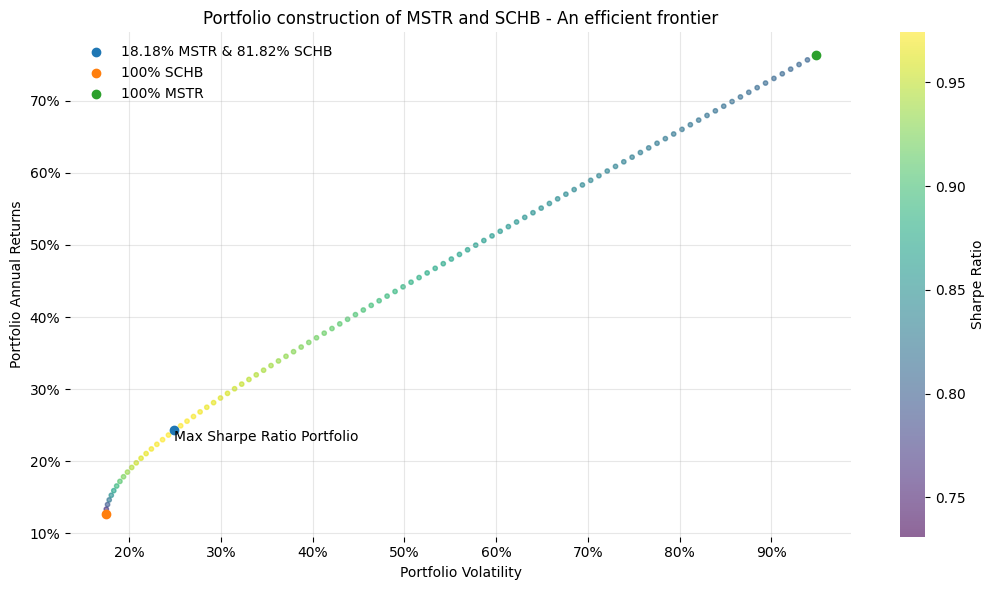

In [62]:
_temp_risky_asset_weight = efficient_frontier.loc[np.argmax(efficient_frontier['sharpe_ratio'])]['risky_asset_weight']
_temp_market_weight = efficient_frontier.loc[np.argmax(efficient_frontier['sharpe_ratio'])]['market_weight']
fig, ax = plt.subplots(figsize=(6*1.77777, 6))
scatter = ax.scatter(efficient_frontier['portfolio_vol'], efficient_frontier['portfolio_return'], 
                     cmap='viridis', s=10, alpha=0.6, c = efficient_frontier['sharpe_ratio'])
cb = fig.colorbar(scatter, label='Sharpe Ratio', drawedges=False)
cb.outline.set_color(None)
ax.scatter(efficient_frontier['portfolio_vol'][np.argmax(efficient_frontier['sharpe_ratio'])],
           efficient_frontier['portfolio_return'][np.argmax(efficient_frontier['sharpe_ratio'])], 
           label=f"{_temp_risky_asset_weight:.2%} {stock_ticker} & {_temp_market_weight:.2%} {market_ticker}")
ax.text(efficient_frontier['portfolio_vol'][np.argmax(efficient_frontier['sharpe_ratio'])], 
        efficient_frontier['portfolio_return'][np.argmax(efficient_frontier['sharpe_ratio'])], 
        "Max Sharpe Ratio Portfolio", ha='left', va='top', fontsize=10)
ax.scatter(efficient_frontier['portfolio_vol'][0], efficient_frontier['portfolio_return'][0], label = f"100% {market_ticker}")
ax.scatter(efficient_frontier['portfolio_vol'].values[-1], efficient_frontier['portfolio_return'].values[-1], label = f"100% {stock_ticker}")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
# ax.spines['bottom'].set_color('#DDDDDD')
ax.set_xlabel("Portfolio Volatility")
ax.set_ylabel("Portfolio Annual Returns")
ax.set_title(f"Portfolio construction of {stock_ticker} and {market_ticker} - An efficient frontier")
ax.legend(loc = "upper left",frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

## Backtest - Optimized Portfolio

In [63]:
class PortfolioBacktester:
    def __init__(self, risky_asset, etf_asset, start_date, end_date, data, returns, initial_capital=100000):
        """
        Initializes the back-testing engine with portfolio parameters.

        Args:
            risky_asset (str): The ticker symbol for the risky stock.
            etf_asset (str): The ticker symbol for the market ETF.
            start_date (str): The start date for the back-test (YYYY-MM-DD).
            end_date (str): The end date for the back-test (YYYY-MM-DD).
            initial_capital (int or float): The starting capital for the portfolio.
        """
        self.risky_asset = risky_asset
        self.etf_asset = etf_asset
        self.tickers = [risky_asset, etf_asset]
        self.start_date = start_date
        self.end_date = end_date
        self.initial_capital = initial_capital        
        self.data = data
        self.returns = returns
        self.portfolio_history = pd.DataFrame(columns=['Date', 'PortfolioValue', 'RiskyWeight', 'ETFWeight'])

    def calculate_efficient_frontier(self, returns):    
        efficient_frontier = pd.DataFrame({"risky_asset_weight" : np.linspace(0, 1, 250)}) #Generate 100 values from 0 to 1. As weights for ASSET
        efficient_frontier['market_weight'] =  1 - efficient_frontier['risky_asset_weight']  #Generate 100 values from 0 to 1. As weights for MARKET
        efficient_frontier['portfolio_return'] =  np.nan
        efficient_frontier['portfolio_vol'] =  np.nan
        
        #Computationally optimized way of computing portfolio return and volatility
        market_return = returns[f'{market_ticker}'].mean()
        market_variance = returns[f'{market_ticker}'].var()
        security_return = returns[f'{stock_ticker}'].mean()
        security_variance = returns[f'{stock_ticker}'].var()
        covariance = returns[f'{stock_ticker}'].cov(returns[f'{market_ticker}'])
        
        # # #Portfolio Return
        efficient_frontier['portfolio_return'] = (efficient_frontier['market_weight'] * market_return +\
                                                             efficient_frontier['risky_asset_weight'] * security_return) * 252
        
        efficient_frontier['portfolio_vol'] = np.sqrt(efficient_frontier['market_weight']**2 * market_variance +\
                                            efficient_frontier['risky_asset_weight']**2 * security_variance + \
                                            efficient_frontier['market_weight'] * efficient_frontier['risky_asset_weight'] * covariance) * np.sqrt(252)
        
        efficient_frontier['sharpe_ratio']  = efficient_frontier['portfolio_return']/efficient_frontier['portfolio_vol']
        
        optimal_weights = efficient_frontier.loc[np.argmax(efficient_frontier['sharpe_ratio']),['risky_asset_weight','market_weight']].values
        weights_record = efficient_frontier[['risky_asset_weight', 'market_weight']].values
        results = efficient_frontier[['portfolio_vol','portfolio_return','sharpe_ratio']].T.values
        
        return optimal_weights, results, weights_record

    def run_backtest(self, rebalance_interval=5):
        """
        Runs the back-testing simulation with periodic rebalancing.
        
        Args:
            rebalance_interval (int): The number of trading days between rebalancing checks.
        """

        portfolio_value = self.initial_capital
        weights_risky = 0
        weights_etf = 0
        holdings_risky = 0
        holdings_etf = 0
        
        # Initial optimization and portfolio setup
        daily_returns = self.returns.iloc[:252]
        optimal_weights, _, _ = self.calculate_efficient_frontier(daily_returns)
        
        # Use a list to store the portfolio's daily value
        portfolio_values = []
        date_index = []

        print(f"Starting back-test with initial capital: ${self.initial_capital:.2f}")

        # The main back-testing loop
        for i in range(len(self.returns)):
            date = self.returns.index[i]
            
            # Rebalance on the first day and every `rebalance_interval` days
            if i == 0 or (i % rebalance_interval) == 0:
                print(f"\n--- Rebalancing on {date.strftime('%Y-%m-%d')} ---")
                
                # Use a rolling window of past data for re-optimization
                lookback_window = self.returns.iloc[max(0, i-252):i]
                if not lookback_window.empty:
                    optimal_weights, _, _ = self.calculate_efficient_frontier(lookback_window)
                    
                weights_risky = optimal_weights[self.tickers.index(self.risky_asset)]
                weights_etf = optimal_weights[self.tickers.index(self.etf_asset)]

                # Recalculate holdings based on current value and new weights
                risky_capital = portfolio_value * weights_risky
                etf_capital = portfolio_value * weights_etf
                
                risky_price = self.data.loc[date, self.risky_asset]
                etf_price = self.data.loc[date, self.etf_asset]
                
                holdings_risky = risky_capital / risky_price
                holdings_etf = etf_capital / etf_price
                
                print(f"Optimal Weights: {self.risky_asset} {weights_risky:.2%}, {self.etf_asset} {weights_etf:.2%}")

            # Update portfolio value based on daily returns
            daily_risky_return = self.returns.loc[date, self.risky_asset]
            daily_etf_return = self.returns.loc[date, self.etf_asset]
            
            holdings_risky *= (1 + daily_risky_return)
            holdings_etf *= (1 + daily_etf_return)
            
            portfolio_value = (holdings_risky * self.data.loc[date, self.risky_asset]) + \
                              (holdings_etf * self.data.loc[date, self.etf_asset])
            
            # Record daily portfolio stats
            date_index.append(date)
            portfolio_values.append(portfolio_value)
            
            # Note: Current weights will fluctuate between rebalances due to market movements
            current_risky_value = holdings_risky * self.data.loc[date, self.risky_asset]
            current_etf_value = holdings_etf * self.data.loc[date, self.etf_asset]
            current_risky_weight = current_risky_value / portfolio_value
            current_etf_weight = current_etf_value / portfolio_value
            
            self.portfolio_history.loc[len(self.portfolio_history)] = [date, portfolio_value, current_risky_weight, current_etf_weight]

        print("\nBack-test completed.")
        final_value = portfolio_values[-1]
        print(f"Final Portfolio Value: ${final_value:.2f}")

In [64]:
portfolio

,timestamp,market_close,market_ret,risky_asset_close,risky_asset_ret
0,2020-12-28,15.12,0.004651,37.00,NaN
1,2020-12-29,15.07,-0.003307,36.61,-0.010541
2,2020-12-30,15.11,0.002654,39.00,0.065283
3,2020-12-31,15.17,0.003971,38.86,-0.003590
4,2021-01-04,14.96,-0.013843,42.52,0.094184
...,...,...,...,...,...
1242,2025-12-08,26.34,-0.003405,183.69,0.026258
1243,2025-12-09,26.33,-0.000380,188.99,0.028853
1244,2025-12-10,26.44,0.004178,184.64,-0.023017
1245,2025-12-11,26.51,0.002648,183.30,-0.007257


In [65]:
import datetime

In [66]:
risky_asset = stock_ticker
etf_asset = market_ticker
tempA = stock_df[['timestamp',"close"]].merge(market_df[['timestamp',"close"]], on="timestamp", how="inner")
tempA.timestamp = pd.to_datetime(tempA.timestamp).dt.date
# tempA.timestamp = tempA.timestamp.map(datetime.datetime.fromisoformat).dt.date
tempA.set_index("timestamp", inplace=True)
tempA.columns = [risky_asset, etf_asset]

tempB = stock_df[['timestamp',"ret"]].merge(market_df[['timestamp',"ret"]], on="timestamp", how="inner")
tempB.timestamp = pd.to_datetime(tempB.timestamp).dt.date
# tempB.timestamp = tempB.timestamp.map(datetime.datetime.fromisoformat).dt.date
tempB.set_index("timestamp", inplace=True)
tempB.columns = [risky_asset, etf_asset]

In [67]:
temp = PortfolioBacktester(risky_asset, etf_asset, tempA.index[0], tempA.index[-1], tempA, tempB.dropna())

In [68]:
temp.run_backtest(rebalance_interval=5)

Starting back-test with initial capital: $100000.00

--- Rebalancing on 2020-12-29 ---
Optimal Weights: MSTR 5.22%, SCHB 94.78%

--- Rebalancing on 2021-01-06 ---
Optimal Weights: MSTR 44.98%, SCHB 55.02%

--- Rebalancing on 2021-01-13 ---
Optimal Weights: MSTR 24.50%, SCHB 75.50%

--- Rebalancing on 2021-01-21 ---
Optimal Weights: MSTR 10.44%, SCHB 89.56%

--- Rebalancing on 2021-01-28 ---
Optimal Weights: MSTR 53.41%, SCHB 46.59%

--- Rebalancing on 2021-02-04 ---
Optimal Weights: MSTR 38.55%, SCHB 61.45%

--- Rebalancing on 2021-02-11 ---
Optimal Weights: MSTR 16.47%, SCHB 83.53%

--- Rebalancing on 2021-02-19 ---
Optimal Weights: MSTR 16.06%, SCHB 83.94%

--- Rebalancing on 2021-02-26 ---
Optimal Weights: MSTR 25.30%, SCHB 74.70%

--- Rebalancing on 2021-03-05 ---
Optimal Weights: MSTR 70.68%, SCHB 29.32%

--- Rebalancing on 2021-03-12 ---
Optimal Weights: MSTR 19.28%, SCHB 80.72%

--- Rebalancing on 2021-03-19 ---
Optimal Weights: MSTR 21.29%, SCHB 78.71%

--- Rebalancing on 2021-

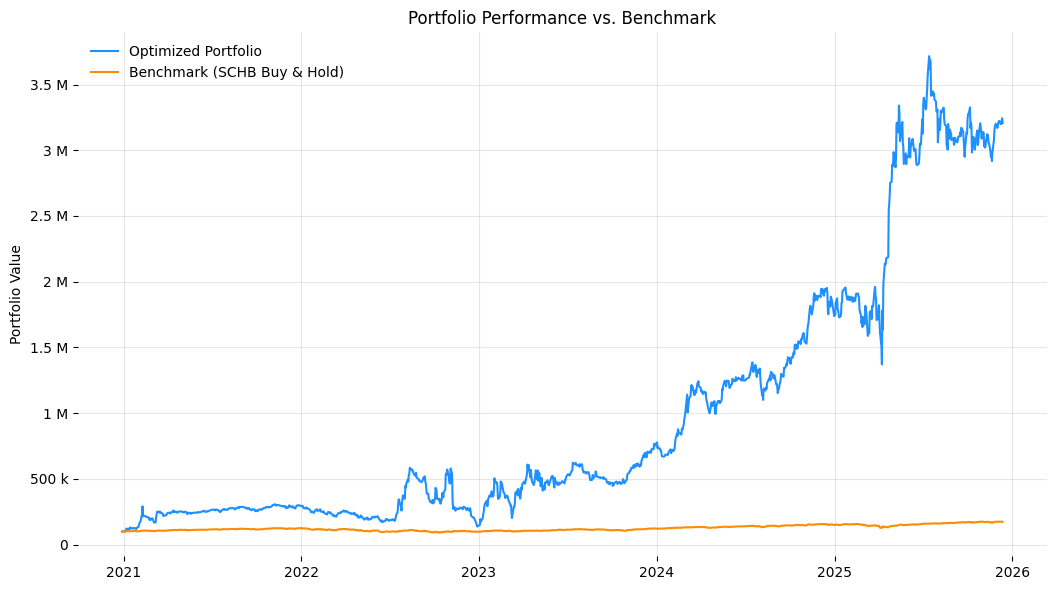

In [69]:
# Prepare benchmark data (buy and hold ETF)
etf_prices = tempA[temp.etf_asset]
benchmark_value = (etf_prices / etf_prices.iloc[0]) * 100_000

plt.style.use('default')
# plt.style.use('rose-pine')
fig, ax1 = plt.subplots(figsize=(6*1.77777, 6))
# Plot portfolio performance
ax1.plot(temp.portfolio_history['Date'], temp.portfolio_history['PortfolioValue'], label='Optimized Portfolio', color='dodgerblue')
ax1.plot(temp.portfolio_history['Date'], benchmark_value.loc[temp.portfolio_history['Date']], label=f'Benchmark ({temp.etf_asset} Buy & Hold)', color='darkorange')
ax1.yaxis.set_major_formatter(EngFormatter())
ax1.set_title('Portfolio Performance vs. Benchmark')
ax1.set_ylabel('Portfolio Value')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.legend(loc = "upper left",frameon=False)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## This is a naive model where it's rebalancing daily but that's not how it's done in the industry. 
## Here are some of the ways it can be improved
- Create a switch to rebalance daily or weekly
- If weekly then select a particular day of the week
- Rebalance based on volatlity threshold
- Rebalance based on correlation